In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Basic load
df_deforestation = pd.read_csv("../data/csv/8-deforestation.csv")
df_power_plants = pd.read_csv("../data/csv/4-power-plants.csv")


  country_code_3  deforestation_count
0            AFG                   17
1            AGO                 5755
2            ALA                   49
3            ALB                  195
4            AND                    2
  country_code_3  forest_count
0            ABW             7
1            AFG           745
2            AGO          2967
3            AIA             4
4            ALA            78
  country  deforestation_count  forest_count  net_forest_change
0     ABW                  0.0             7                7.0
1     AFG                 17.0           745              728.0
2     AGO               5755.0          2967            -2788.0
3     AIA                  0.0             4                4.0
4     ALA                 49.0            78               29.0
  country  plant_count country_name  deforestation_count  forest_count  \
0     ARG          231    Argentina               6744.0         15242   
1     AUS          429    Australia               9224

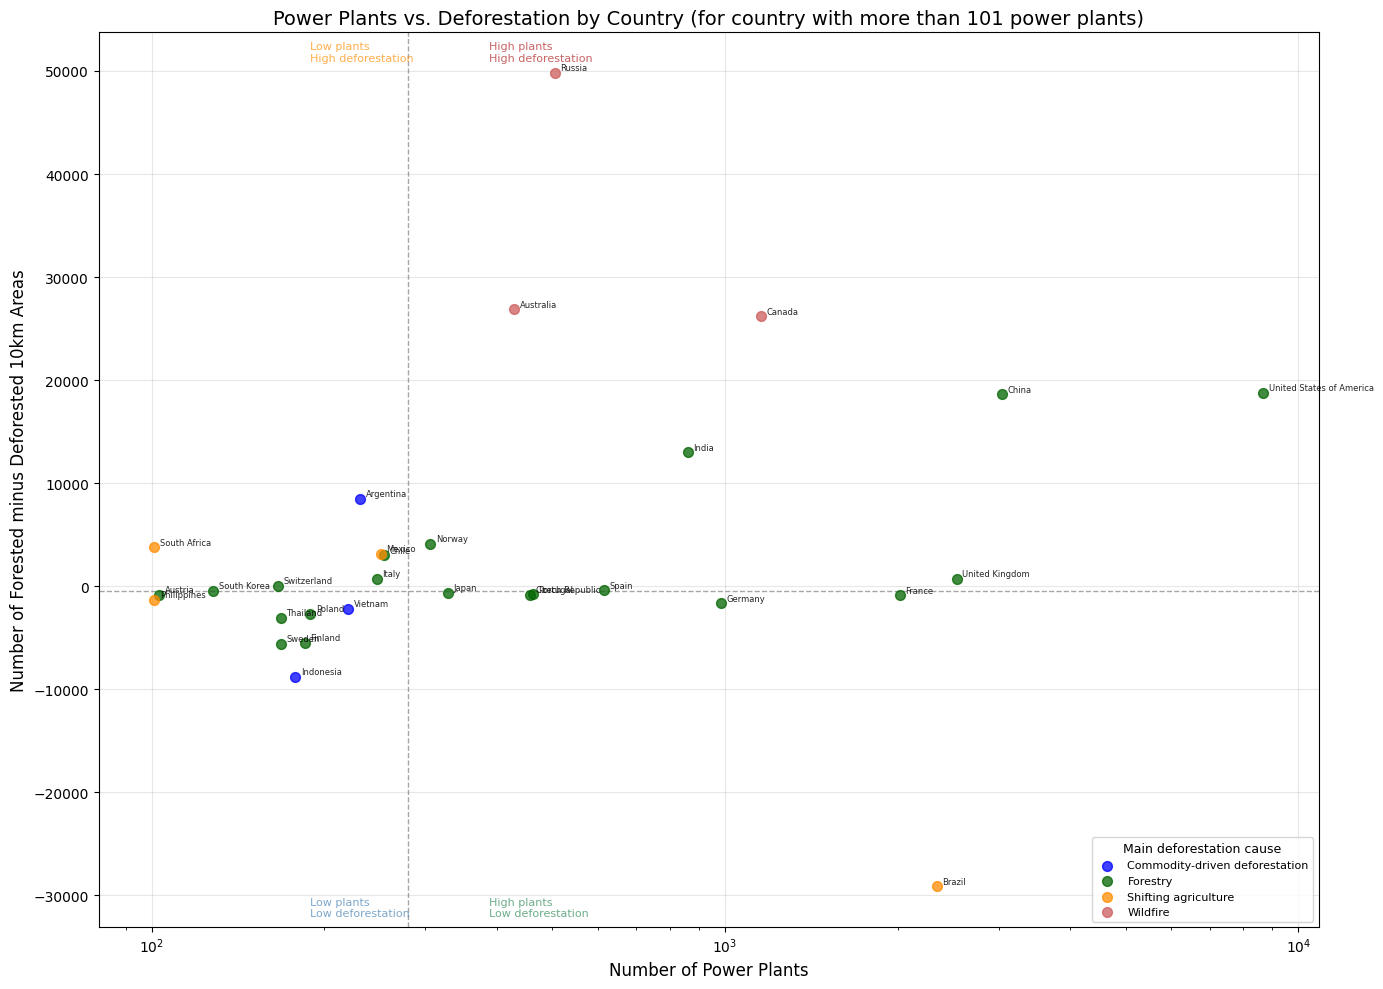

In [40]:
# --- Aggregate ---
# Count deforested 10km pixels per country (exclude "No loss")
defor_counts = (
    df_deforestation[df_deforestation["cause"] != "No loss"]
    .groupby("country_code_3")
    .size()
    .reset_index(name="deforestation_count")
)
print(defor_counts.head())
forest_counts = (
    df_deforestation[df_deforestation["cause"] == "No loss"]
    .groupby("country_code_3")
    .size()
    .reset_index(name="forest_count")
)
print(forest_counts.head())
diff_forest_counts = pd.merge(defor_counts, forest_counts, on="country_code_3", how="outer").fillna(0)
diff_forest_counts["net_forest_change"] = diff_forest_counts["forest_count"] - diff_forest_counts["deforestation_count"]
diff_forest_counts.rename(columns={"country_code_3": "country"}, inplace=True)
print(diff_forest_counts.head())

# Count power plants per country, keep country name
plant_counts = (
    df_power_plants.groupby("country")  # 2-letter code
    .agg(plant_count=("country", "count"), country_name=("country_long", "first"))
    .reset_index()
)
plant_counts = plant_counts[plant_counts["plant_count"] > 100]

# Dominant deforestation cause per country
dominant_cause = (
    df_deforestation[df_deforestation["cause"] != "No loss"]
    .groupby(["country_code_3", "cause"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .drop_duplicates("country_code_3")
    .rename(columns={"country_code_3": "country"})[["country", "cause"]]
)

# --- Merge (only countries with at least one power plant) ---
merged = plant_counts.merge(diff_forest_counts, on="country", how="left")
# Merge it into the main dataframe
merged = merged.merge(dominant_cause, on="country", how="left")
merged["cause"] = merged["cause"].fillna("Unknown")
print(merged.head())
merged["net_forest_change"] = merged["net_forest_change"].fillna(0)

# --- Compute quadrant thresholds (medians) ---
med_x = merged["plant_count"].median()
print(f"Median plant count: {med_x}")
med_y = merged["net_forest_change"].median()
print(f"Median net forest change: {med_y}")


# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10))

CAUSE_COLORS = {
    "Commodity-driven deforestation": "blue",
    "Shifting agriculture": "darkorange",
    "Forestry": "darkgreen",
    "Wildfire": "indianred",
    "Urbanization": "blue",
    "Unknown": "lightgray",
}

for cause, group in merged.groupby("cause"):
    ax.scatter(
        group["plant_count"],
        group["net_forest_change"],
        alpha=0.75,
        s=50,
        color=CAUSE_COLORS.get(cause, "steelblue"),
        label=cause,
        zorder=3,
    )

ax.legend(
    title="Main deforestation cause", fontsize=8, title_fontsize=9, loc="lower right"
)

# Label each country
for _, row in merged.iterrows():
    ax.annotate(
        row["country_name"],
        xy=(row["plant_count"], row["net_forest_change"]),
        fontsize=6,
        alpha=0.85,
        textcoords="offset points",
        xytext=(4, 2),
    )

ax.set_xscale("log")

# Quadrant lines
ax.axvline(med_x, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Quadrant labels
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
pad_x = (x_max - x_min) * 0.01
pad_y = (y_max - y_min) * 0.01

ax.text(
    med_x + pad_x,
    y_max - pad_y,
    "High plants\nHigh deforestation",
    va="top",
    ha="left",
    fontsize=8,
    color="firebrick",
    alpha=0.7,
)
ax.text(
    x_min + pad_x,
    y_max - pad_y,
    "Low plants\nHigh deforestation",
    va="top",
    ha="left",
    fontsize=8,
    color="darkorange",
    alpha=0.7,
)
ax.text(
    med_x + pad_x,
    y_min + pad_y,
    "High plants\nLow deforestation",
    va="bottom",
    ha="left",
    fontsize=8,
    color="seagreen",
    alpha=0.7,
)
ax.text(
    x_min + pad_x,
    y_min + pad_y,
    "Low plants\nLow deforestation",
    va="bottom",
    ha="left",
    fontsize=8,
    color="steelblue",
    alpha=0.7,
)

ax.set_xlabel("Number of Power Plants", fontsize=12)
ax.set_ylabel("Number of Forested minus Deforested 10km Areas", fontsize=12)
ax.set_title(f"Power Plants vs. Deforestation by Country (for country with more than {plant_counts['plant_count'].min()} power plants)", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
